About DataSet:
Credit score cards are a common risk control method in the financial industry. It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings. The bank is able to decide whether to issue a credit card to the applicant. Credit scores can objectively quantify the magnitude of risk.

Generally speaking, credit score cards are based on historical data. Once encountering large economic fluctuations. Past models may lose their original predictive power. Logistic model is a common method for credit scoring. Because Logistic is suitable for binary classification tasks and can calculate the coefficients of each feature. In order to facilitate understanding and operation, the score card will multiply the logistic regression coefficient by a certain value (such as 100) and round it.
https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction/data

Framing Problem Statement:
Predicting Credit Card Approval Status Based on Customer Demographics and Financial Data

Using the provided dataset, we aim to develop a machine learning model that predicts whether a customer's credit card application will be approved or denied (Status) based on various demographic and financial features, including income amount, family size, employment duration, and age. The goal is to build a predictive model that can classify applicants into approved or denied categories with high accuracy, providing insights into key factors that influence credit card approval decisions. We will apply various machine learning algorithms (e.g., Logistic Regression, Decision Trees, Random Forests) to optimize the model's performance and assess the impact of different features on approval outcomes.

This problem can be framed as a binary classification task, where the target variable is Status (approved or denied).

Importing the Dataset

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download the dataset
path = kagglehub.dataset_download("rikdifos/credit-card-approval-prediction")
print("Path to dataset files:", path)

# Load the datasets into variables


# Replace 'file1.csv' and 'file2.csv' with the actual filenames
file1_path = f"{path}/application_record.csv"  # Replace with the correct file name
file2_path = f"{path}/credit_record.csv"  # Replace with the correct file name

data1 = pd.read_csv(file1_path)
data2 = pd.read_csv(file2_path)

# Display basic information about the datasets
print("Dataset 1 Info:")
print(data1.info())
print("\nDataset 2 Info:")
print(data2.info())

# Perform basic EDA
print("\nDataset 1 Head:")
print(data1.head())

print("\nDataset 2 Head:")
print(data2.head())

print("\nDataset 1 Summary Statistics:")
print(data1.describe())

print("\nDataset 2 Summary Statistics:")
print(data2.describe())

100%|██████████| 5.32M/5.32M [00:00<00:00, 43.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rikdifos/credit-card-approval-prediction/versions/3
Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 

# New Section

In [2]:
object_columns = data1.select_dtypes(include=['object']).columns
print(object_columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='object')


In [3]:
for col in object_columns:
    d_type = data1[col].dtype

    counts =data1[col].value_counts()
    print(f"Counts for {col}:")
    print(counts)
    print("============================================================")

Counts for CODE_GENDER:
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64
Counts for FLAG_OWN_CAR:
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64
Counts for FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64
Counts for NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64
Counts for NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64
Counts for NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: in

Handling the Null Values in the Dataset

In [4]:
# Check for missing values
print("\nMissing Values in Dataset 1:")
print(data1.isnull().sum())

print("\nMissing Values in Dataset 2:")
print(data2.isnull().sum())




Missing Values in Dataset 1:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Missing Values in Dataset 2:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In Data-1 found the Missing Values in the Occupuation type in order to over come we are creating function makes sure that the DataFrame's category columns include no missing values. A popular imputation technique for categorical data is to substitute the mode of each column for missing values when:

There aren't many distinct categories in the column.
The general distribution of the column is reflected in the mode.


In [5]:
missing_columns = [col for col in data1.columns if data1[col].isnull().sum() > 0]
data1[missing_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 1 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   OCCUPATION_TYPE  304354 non-null  object
dtypes: object(1)
memory usage: 3.3+ MB


In [6]:
print(data1.isnull().sum())

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64


Checking for the Duplicate Values

In [7]:
# Check for duplicate values in the 'ID' column of Dataset 1
duplicates_in_ID_data1 = data1['ID'].duplicated().sum()
print(f"Number of duplicate 'ID' values in Dataset 1: {duplicates_in_ID_data1}")

# Check for duplicate values in the 'ID' column of Dataset 2 (if applicable)
if 'ID' in data2.columns:
    duplicates_in_ID_data2 = data2['ID'].duplicated().sum()
    print(f"Number of duplicate 'ID' values in Dataset 2: {duplicates_in_ID_data2}")
else:
    print("Dataset 2 does not have an 'ID' column.")

# Optional: Display duplicate 'ID' rows if needed
if duplicates_in_ID_data1 > 0:
    print("\nDuplicate 'ID' values in Dataset 1:")
    print(data1[data1['ID'].duplicated(keep=False)])

if 'ID' in data2.columns and duplicates_in_ID_data2 > 0:
    print("\nDuplicate 'ID' values in Dataset 2:")
    print(data2[data2['ID'].duplicated(keep=False)])


Number of duplicate 'ID' values in Dataset 1: 47
Number of duplicate 'ID' values in Dataset 2: 1002590

Duplicate 'ID' values in Dataset 1:
             ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
421211  7702516           F            N               Y             2   
421268  7602432           M            N               Y             0   
421349  7602432           F            N               N             0   
421464  7836971           M            Y               N             1   
421698  7213374           M            Y               N             0   
...         ...         ...          ...             ...           ...   
433158  7282535           F            N               Y             0   
433159  7742853           M            N               Y             0   
433217  7135270           F            N               Y             0   
433666  7091721           F            Y               Y             0   
433789  7618285           F            N      

In [8]:
data1 = data1.drop_duplicates(subset='ID',keep='first')
data2 = data2.drop_duplicates(subset='ID',keep='first')

In [9]:
data1['ID'].duplicated().sum()
data2['ID'].duplicated().sum()

0

Feature ENgineering

In [10]:
data2['STATUS'].value_counts()

,count
STATUS,
C,22707
X,12266
0,10547
1,353
5,82
2,19
3,6
4,5


In [11]:
# def classify_client(status):
#     if status in ['C', 'X', '0']:
#         return 'Very Good'

#     elif status in ['1']:
#         return 'Good'

#     elif status in ['2', '3']:
#         return 'Not Bad'

#     elif status in ['4']:
#         return 'Bad'

#     elif status in ['5']:
#         return 'Very Bad'

#     else:
#         return 'Unknown'


# data2['STATUS'] = data2['STATUS'].apply(classify_client)
# print(data2['STATUS'].value_counts())


In [12]:
# def retrieve_data(status):
#     if status in ['Very Good']:
#         return 1

#     elif status in ['Good']:
#         return 2

#     elif status in ['Not Bad']:  # corrected this line
#         return 3

#     elif status in ['Bad']:
#         return 4

#     elif status in ['Very Bad']:
#         return 5

#     else:
#         return 0

# data2['STATUS'] = data2['STATUS'].apply(retrieve_data)
# print(data2['STATUS'].value_counts())

In [13]:
credit_status = data2.groupby('ID')['STATUS'].agg("max").reset_index()
months_balance = data2.groupby('ID')['MONTHS_BALANCE'].agg("max").reset_index()

# Merging the dataframes

data1 = pd.merge(data1, credit_status, how='inner', on='ID')
data1 = pd.merge(data1, months_balance, how='inner', on='ID')

In [14]:
data1 = data1.sort_values('AMT_INCOME_TOTAL')
data1 = data1.reset_index(drop=True)
data1.ID=data1.index
data1.columns = ('User_id',
              'Gender',
              'Car',
              'Realty',
              'children_count',
              'income_amount',
              'income_type',
              'education_type',
              'Family_status',
              'Housing_type',
              'Days_birth',
              'Days_employed',
              'Mobile',
              'Work_phone',
              'Phone',
              'Email',
              'Occupation_type',
              'Count_family_members',
              'Status',
              'Month_Balance'
              )

In [15]:
df=data1
# Drop the 'Occupation_type' column as it contains missing values
df = df.drop(columns=['Occupation_type'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_id               36457 non-null  int64  
 1   Gender                36457 non-null  object 
 2   Car                   36457 non-null  object 
 3   Realty                36457 non-null  object 
 4   children_count        36457 non-null  int64  
 5   income_amount         36457 non-null  float64
 6   income_type           36457 non-null  object 
 7   education_type        36457 non-null  object 
 8   Family_status         36457 non-null  object 
 9   Housing_type          36457 non-null  object 
 10  Days_birth            36457 non-null  int64  
 11  Days_employed         36457 non-null  int64  
 12  Mobile                36457 non-null  int64  
 13  Work_phone            36457 non-null  int64  
 14  Phone                 36457 non-null  int64  
 15  Email              

**Upendra Data Visualisation**

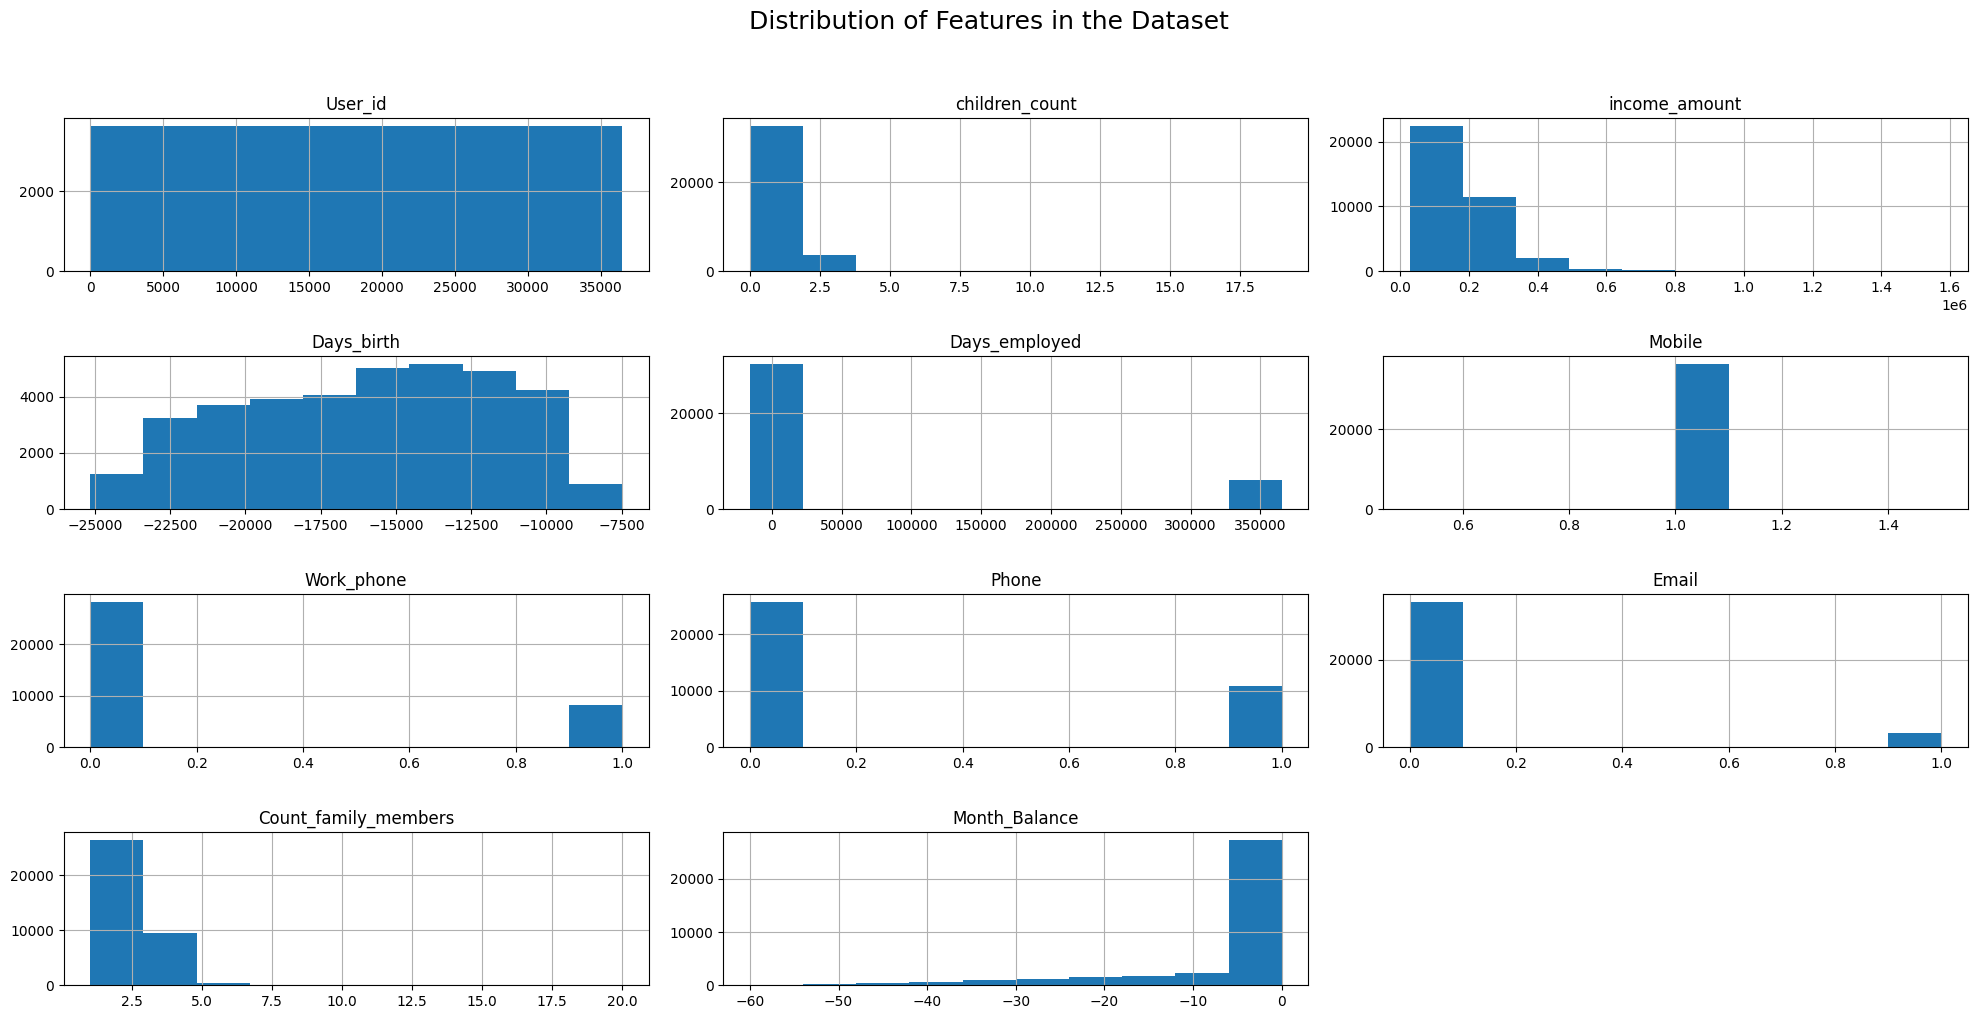

In [16]:
import matplotlib.pyplot as plt

# Create the histograms
df.hist(figsize=(20, 10))

# Set the figure title
plt.suptitle("Distribution of Features in the Dataset", fontsize=18, y=1.02)  # Title with font size and adjusted position

# Adjust text visibility
plt.rcParams.update({'font.size': 14})  # Set font size for all elements
plt.tight_layout()  # Adjust layout to prevent overlap

# Display the plots
plt.show()


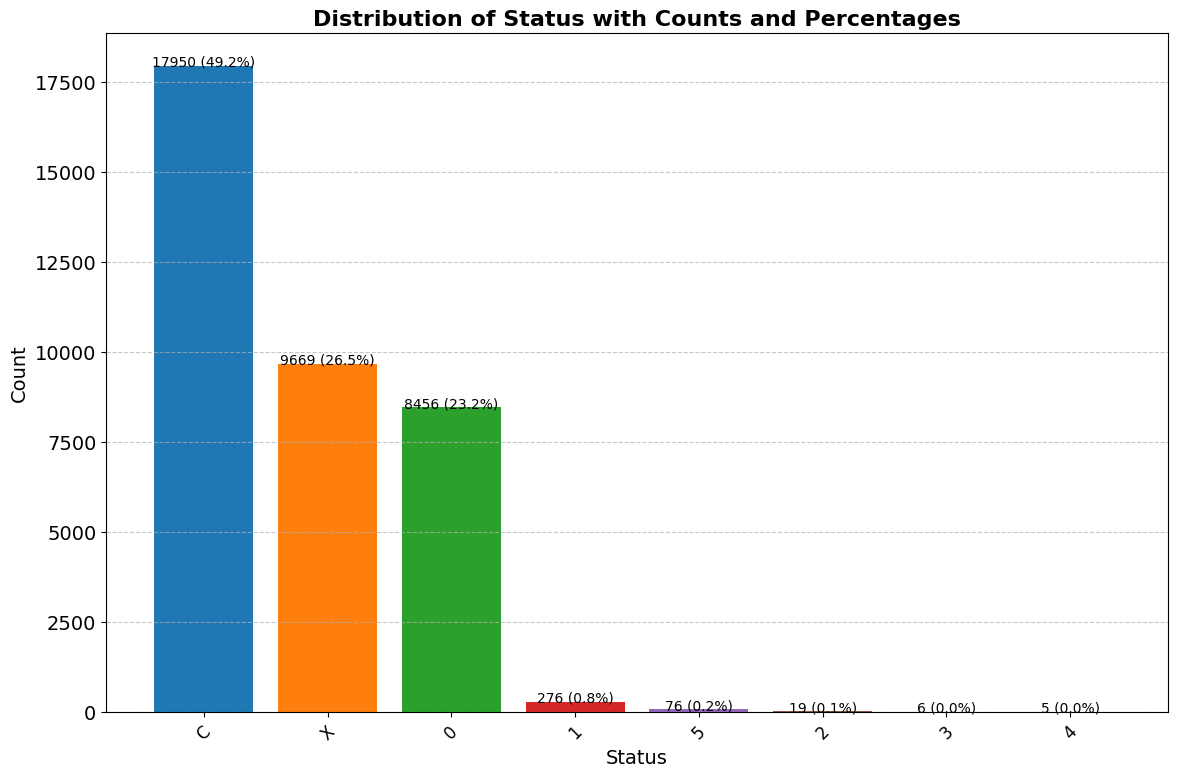

In [17]:
def plot_bar_single(column):
    # Calculate counts and percentages
    target_column = df[column].value_counts()
    percentages = (target_column / target_column.sum()) * 100

    # Create the figure and bar plot
    plt.figure(figsize=(12, 8))
    bars = plt.bar(target_column.index, target_column.values, color=plt.cm.tab10(range(len(target_column))))

    # Add data labels with counts and percentages
    for bar, count, percent in zip(bars, target_column.values, percentages):
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center of the bar
            bar.get_height() + 0.5,            # Slightly above the bar
            f'{count} ({percent:.1f}%)',       # Format: Count (Percentage)
            ha='center', fontsize=10
        )

    # Set descriptive title and axis labels
    plt.title(f"Distribution of {column} with Counts and Percentages", fontsize=16, fontweight='bold')
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # Rotate x-axis labels for better readability (if needed)
    plt.xticks(rotation=45, fontsize=12)

    # Add gridlines for clarity
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
plot_bar_single("Status")


The graph illustrates the distribution of loan repayment statuses, with the majority (99%) falling into the **1-29 days past due (Status 0)** category, indicating minor delays in repayment. Severe overdue statuses, from **30-59 days (Status 1)** to **150+ days (Status 5)**, represent less than 1% collectively, highlighting their rarity. This suggests that most borrowers maintain good repayment practices, with only a small fraction experiencing significant delays. The chart emphasizes the need to focus on early intervention for borrowers showing escalating delays.

Lokesh Data Visualisation

Graph For Comparing the Numerical Columns and Categorical Columns

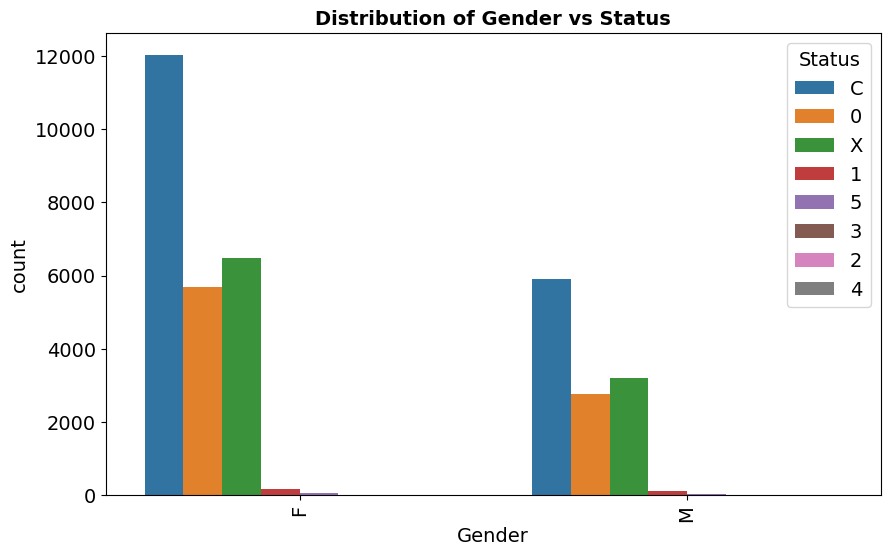

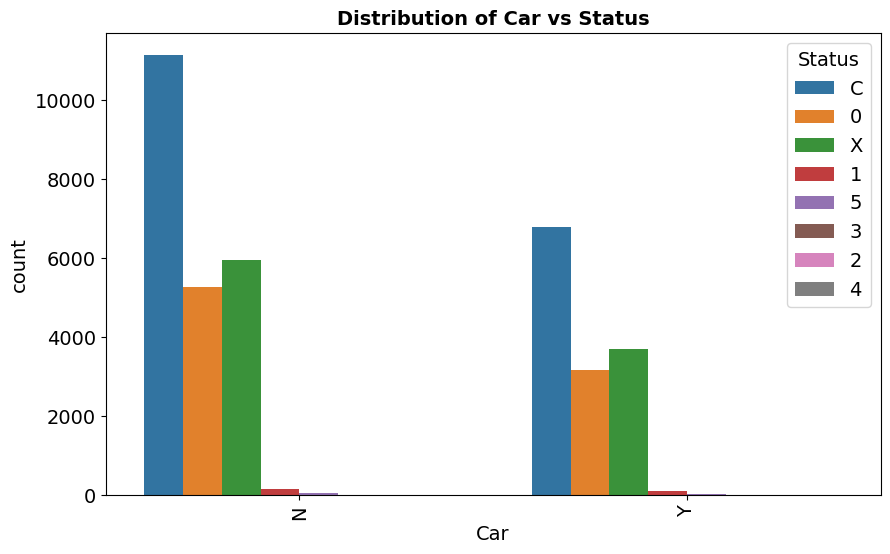

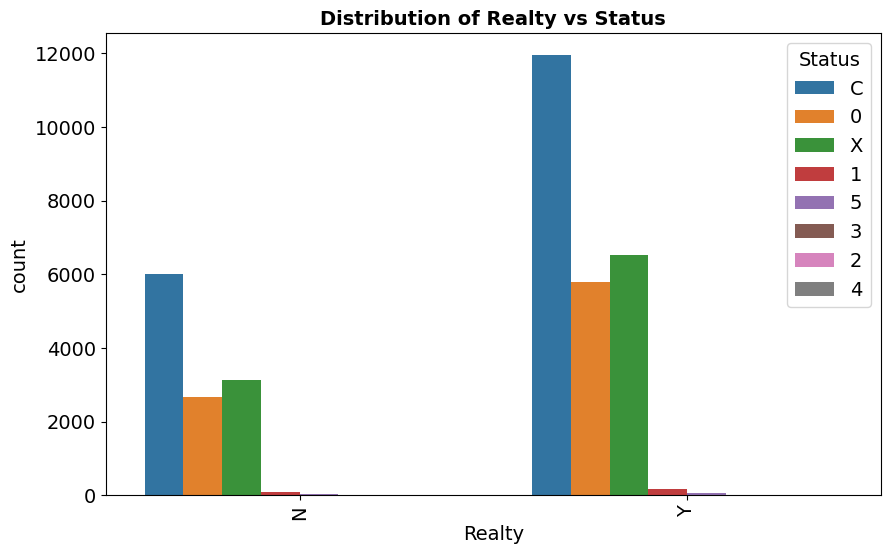

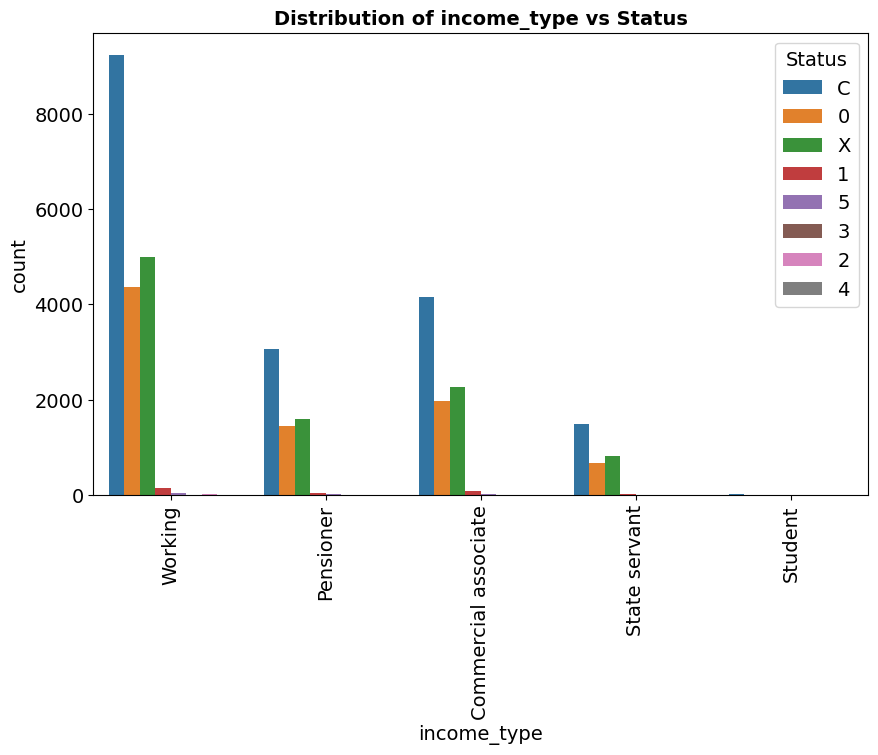

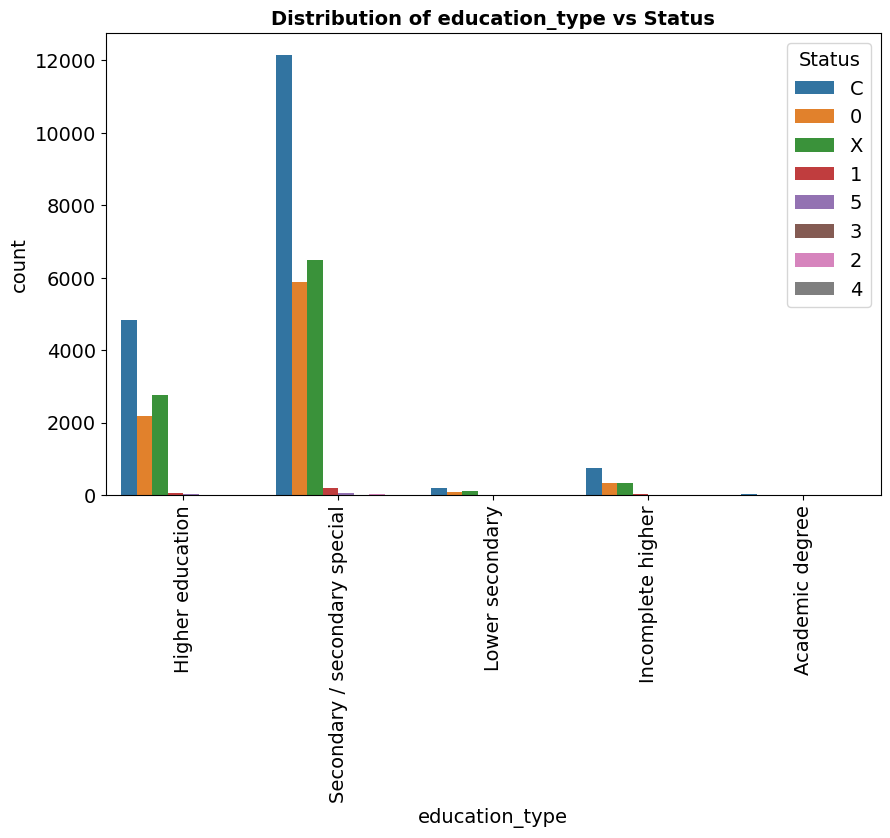

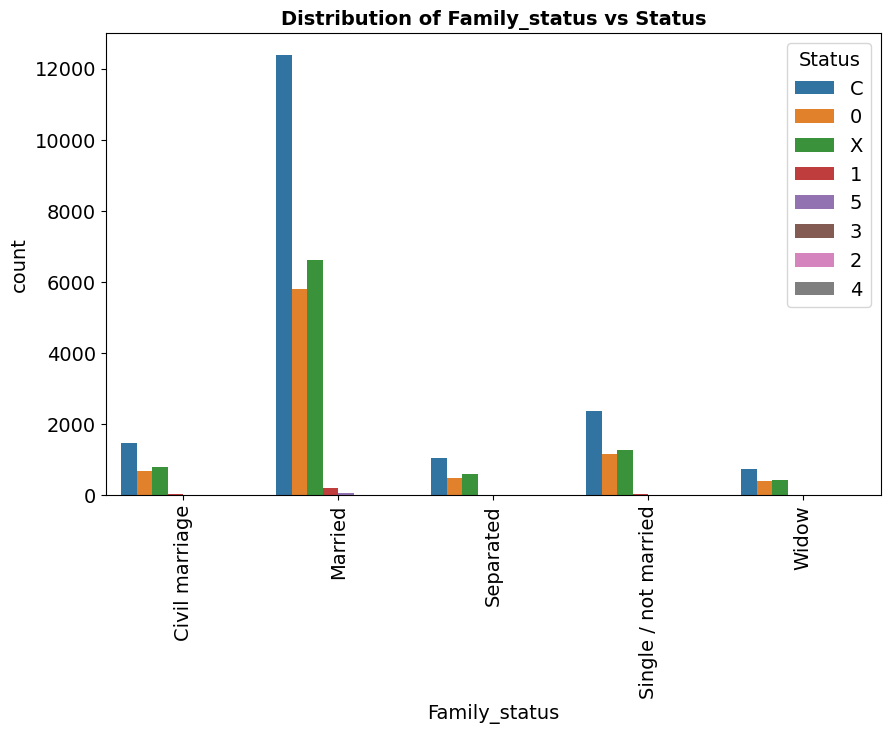

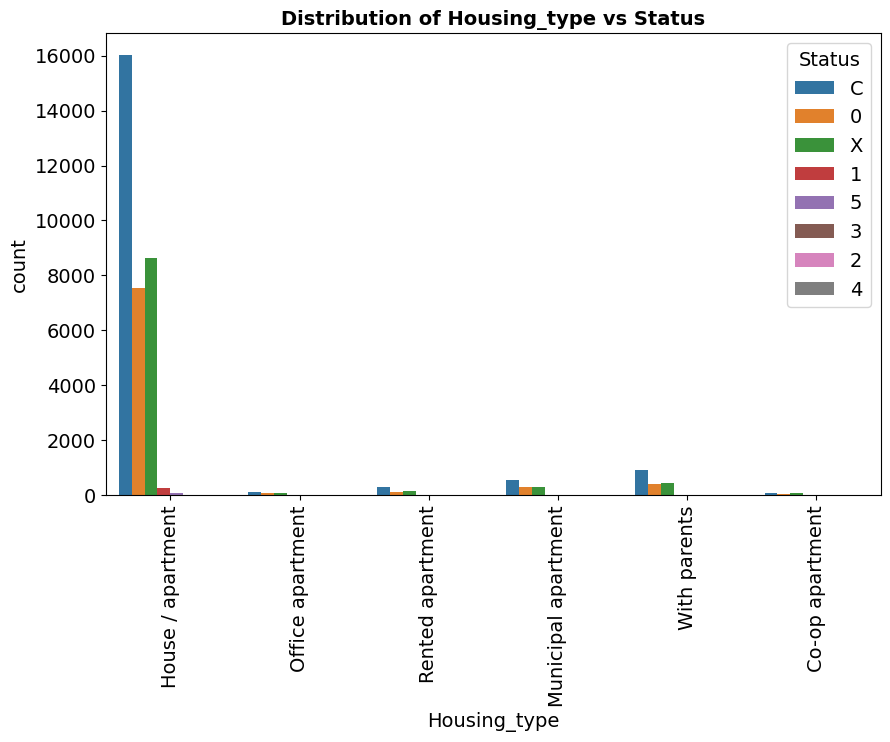

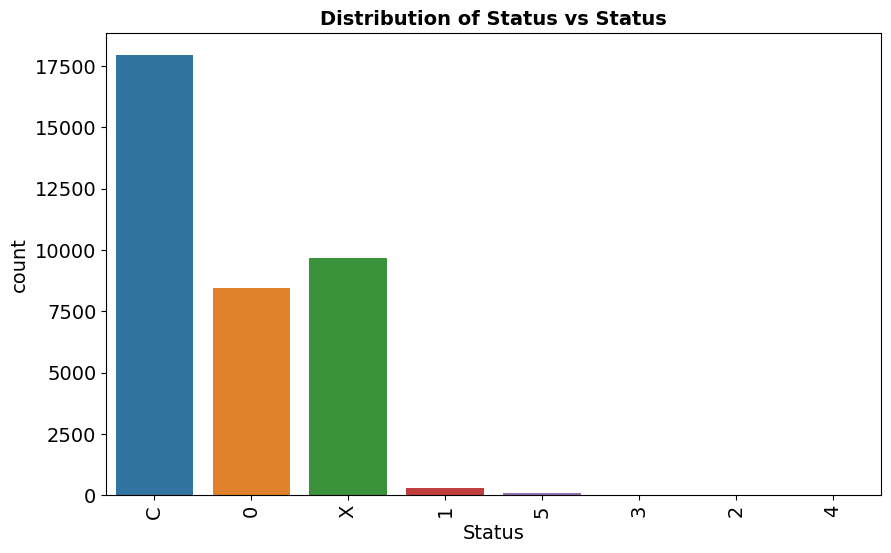

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
  plt.figure(figsize=(10,6))
  sns.countplot(data=df,x=col,hue= 'Status' )
  plt.title(f'Distribution of {col} vs Status', fontweight="bold", size=14)
  plt.xticks(rotation=90)
  plt.show()
  print("\n")

The distribution of categorical feature in the dataset, displaying the distribution of values within each category, segmented by the 'Status' variable. The hue='Status' argument ensures that the distribution is colored according to the different statuses, allowing for comparison across the categories. The plt.xticks(rotation=90) ensures that the x-axis labels (categories) are rotated 90 degrees for better readability, especially when the category names are long. Each plot is displayed individually with a title indicating the feature being visualized against the 'Status'. This approach helps to understand the relationship between categorical variables and the 'Status' variable.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_id               36457 non-null  int64  
 1   Gender                36457 non-null  object 
 2   Car                   36457 non-null  object 
 3   Realty                36457 non-null  object 
 4   children_count        36457 non-null  int64  
 5   income_amount         36457 non-null  float64
 6   income_type           36457 non-null  object 
 7   education_type        36457 non-null  object 
 8   Family_status         36457 non-null  object 
 9   Housing_type          36457 non-null  object 
 10  Days_birth            36457 non-null  int64  
 11  Days_employed         36457 non-null  int64  
 12  Mobile                36457 non-null  int64  
 13  Work_phone            36457 non-null  int64  
 14  Phone                 36457 non-null  int64  
 15  Email              

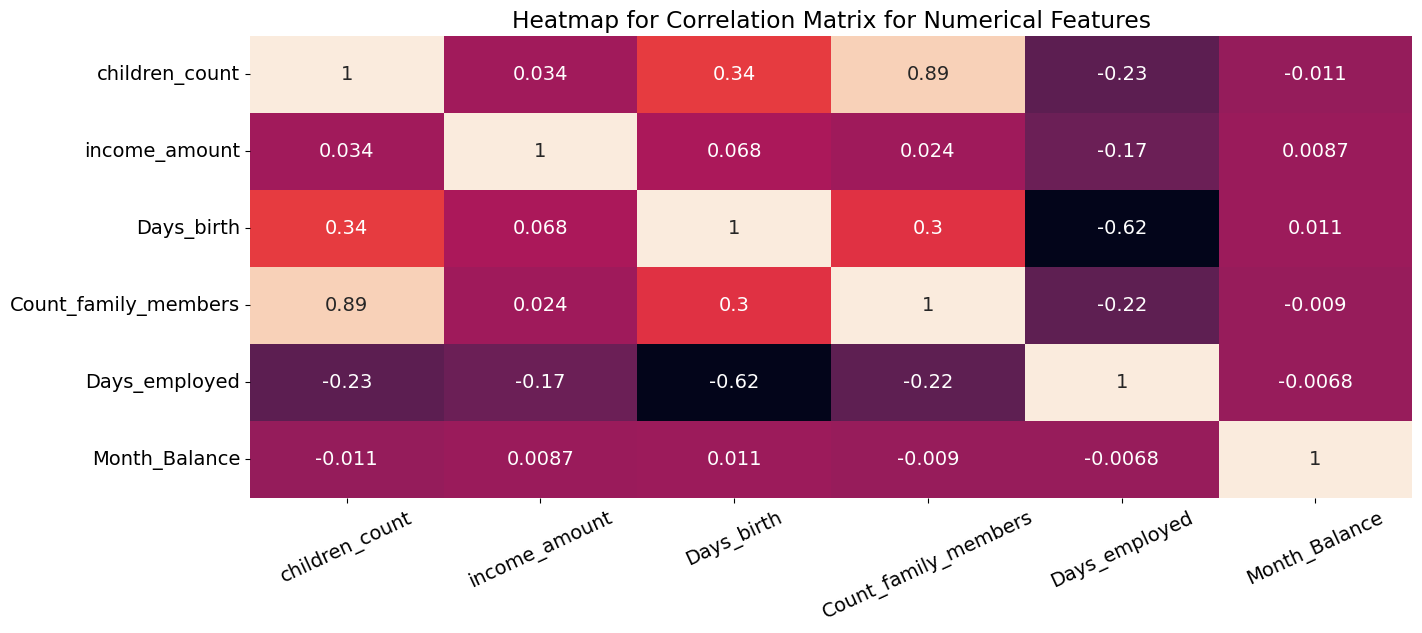

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the figure size
plt.figure(figsize=(15, 6))

# Plotting the heatmap with the updated column names
sns.heatmap(df[['children_count', 'income_amount', 'Days_birth', 'Count_family_members', 'Days_employed', 'Month_Balance']].corr(), annot=True, cbar=False)

# Define the title and rotation of x-axis labels
plt.xticks(rotation=25)
plt.title('Heatmap for Correlation Matrix for Numerical Features')

# Show the heatmap
plt.show()


Several important findings are revealed by the correlation heatmap: `User_id` and `income_amount` have a substantial positive connection (0.85), even though `User_id` might not be a useful feature for analysis. The strong correlation (0.89) between `children_count` and `Count_family_members` suggests that they are redundant. `Days_birth` and `Days_employed` exhibit a moderately negative association (-0.62), indicating that older people often have shorter employment durations. The majority of other attributes, such as `Mobile`, `Work_phone`, and `Phone`, exhibit little or insignificant associations with the target variable ({Status`). Overall, eliminating one of the strongly correlated features, such as `children_count` and `Count_family_members`, may help to decrease redundancy.


Aravind Data Visualisation

In [21]:
# # Pairplot for selected numerical columns
# selected_columns = num_col[:4]  # Select the first 4 numerical columns (adjust as needed)
# sns.pairplot(df, vars=selected_columns, hue="Status", palette="husl", diag_kind="kde", height=2.5)

# # Update the title and axes font sizes
# plt.suptitle("Pairplot of Numerical Variables", fontweight="bold", size=18, color="darkblue", y=1.02)
# plt.subplots_adjust(top=0.95)  # Adjust the title position to avoid overlapping with the plot
# plt.xticks(fontsize=12)  # Increase x-axis font size
# plt.yticks(fontsize=12)  # Increase y-axis font size

# plt.show()


This pairplot, which uses `Status` as the color, displays the associations between `children_count`, `income_amount`, and `Days_birth`. `User_id` doesn't seem to be a useful identification. There is a weak positive trend between the two variables, with the majority of users having low `children_count` and incomes under one million. The distribution of `Days_birth` (age) is unimodal, but there is no discernible relationship between it and other variables. There are no obvious clusters based on `Status`, indicating that more research is required to find trends.

Visualisation For All Data Features

<ipython-input-22-d73ce17451f2>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Status', y='income_amount', palette='viridis', ci=None)
<ipython-input-22-d73ce17451f2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Status', y='income_amount', palette='viridis', ci=None)


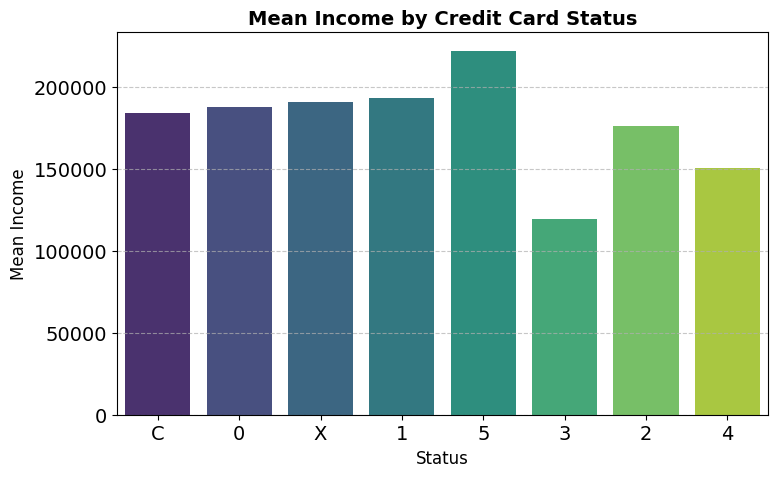

In [22]:

# Barplot of mean income by status
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Status', y='income_amount', palette='viridis', ci=None)
plt.title("Mean Income by Credit Card Status", fontweight="bold", size=14)
plt.xlabel("Status", fontsize=12)
plt.ylabel("Mean Income", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The mean income for each credit card status is shown in this bar chart. It demonstrates that the mean income of people with credit card level 5 is the highest, whilst the mean earnings of those with statuses 3 and 4 are relatively lower. There may be a connection between income and credit card status, as the trend suggests that higher statuses (such as 5) may be associated with greater income levels. This association could be examined in further detail in future research.

Adityaa Data Visualisation

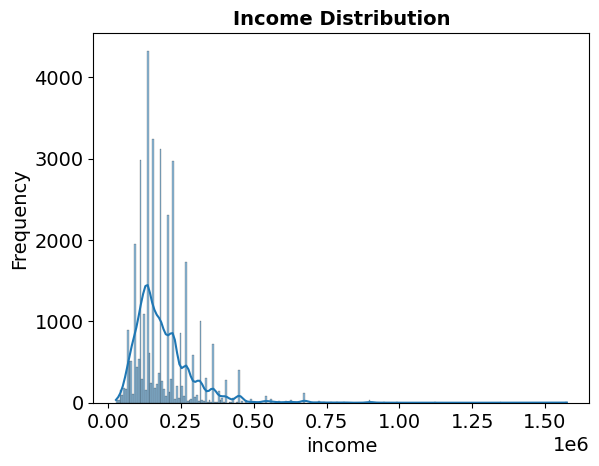

In [23]:
income_plot = pd.Series(df.income_amount, name="income")
plt.ylabel('Frequency')
sns.histplot(income_plot, kde=True)
plt.title('Income Distribution', fontweight="bold", size=14)
plt.show()

The graph's representation of the income distribution is extremely right-skewed, with the bulk of people making less than 0.25 million. For higher income levels, the frequency drops off dramatically, suggesting that very few people make a lot of money. This pattern highlights income disparity in the dataset by pointing to a typical income distribution in which a tiny fraction of people earn significantly higher incomes than the majority.

In [24]:
import plotly.express as px  # Import Plotly Express

# Create an interactive scatterplot
fig = px.scatter(
    df,
    x="income_amount",
    y="Status",
    title="Person Income by Loan Amount",
    labels={"income_amount": "Income Amount", "Status": "Loan Status"},
    template="plotly_white",
    color="Status",  # Optional: Differentiate points by 'Status'
)

# Customize title font
fig.update_layout(title_font=dict(size=18, family="Arial", color="black"))

# Display the interactive graph
fig.show()


The graph illustrates the relationship between income amount and loan status. Individuals with lower income amounts generally have lower loan statuses, indicating limited loan approval likelihood. Those with moderate incomes (200K–400K) tend to have higher loan statuses, suggesting this range may be favorable for approvals. However, outliers exist where individuals with very high incomes (e.g., 1.6M) have lower loan statuses, highlighting the influence of other factors beyond income on loan decisions. This emphasizes that while income is significant, additional factors likely impact loan approval outcomes.

Sashank Data Visualisation

In [25]:
import plotly.express as px
import pandas as pd

# Convert days to age
df['age'] = df.Days_birth.apply(lambda x: int(-x / 365.25))

# Create interactive histogram with age distribution
fig = px.histogram(df,
                   x="age",
                   title="Age Distribution of Loan Applicants",
                   nbins=30,  # Number of bins
                   labels={'age': 'Age'},  # X-axis label
                   height=600,  # Set figure height
                   width=800  # Set figure width
                  )

# Update layout for a polished look
fig.update_layout(
    title_font=dict(size=18, family='Arial', color='black'),  # Title style
    xaxis_title="Age",  # X-axis title
    yaxis_title="Frequency",  # Y-axis title
    template="plotly_dark",  # Dark theme for modern feel
    xaxis=dict(showgrid=False),  # Disable gridlines for a cleaner look
    yaxis=dict(showgrid=True, gridcolor='rgba(255, 255, 255, 0.2)'),  # Subtle gridlines
    bargap=0.2,  # Slight space between bars
)

# Show the interactive plot
fig.show()


The graph shows how loan applications are distributed by age, with the 30 to 50 age group showing the highest frequency. This implies that people in this group are more likely to request for loans, perhaps as a result of financial obligations like family necessities, schooling, or home ownership. With comparatively fewer applicants in their early 20s or beyond 60, the distribution declines on both ends. This is probably due to their age groups' lower financial need or eligibility restrictions. This trend offers insightful information about how to target particular age groups with financial products.

In [26]:
import plotly.express as px
import numpy as np

# Group and aggregate data
df_grouped = df.groupby(["education_type", "income_type"])["income_amount"].sum().reset_index()

# Rename columns for better readability
df_grouped.columns = ["Education Type", "Income Type", "Total Income"]

# Sort values for a structured treemap
df_grouped = df_grouped.sort_values(by=["Education Type", "Income Type"])

# Create the treemap visualization
fig = px.treemap(
    df_grouped,
    path=["Education Type", "Income Type"],  # Define hierarchy
    values="Total Income",  # Value to size the boxes
    color="Total Income",  # Color intensity based on total income
    hover_data={"Total Income": ":.2f", "Education Type": False, "Income Type": False},  # Customize hover
    color_continuous_scale="Blues",  # Use a visually appealing color scale
    color_continuous_midpoint=np.median(df_grouped["Total Income"])  # Median as color midpoint
)

# Update layout for a polished appearance
fig.update_layout(
    title=dict(
        text="Total Income Distribution by Education and Income Type",
        font=dict(size=20, family="Arial", color="black"),
        x=0.5,  # Center align
        xanchor="center"
    ),
    margin=dict(t=60, l=30, r=30, b=30),  # Adjust margins
    height=800  # Adjust height
)

# Display the treemap
fig.show()


The distribution of total income, broken down by income categories and educational attainment, is displayed in the treemap. The highest portion of overall revenue is earned by working individuals with secondary or secondary special education. Higher education students who are classified as "working" also make a substantial contribution to the income pool. However, groups like state employees and retirees, particularly those with less education, make up a smaller share of the overall income.


Working professionals in both secondary and higher education categories dominate the income landscape, according to this data, which also shows a strong correlation between employment type and education level and income distribution.


In [27]:
pip install umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

<ipython-input-28-91655edca4a0>:35: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



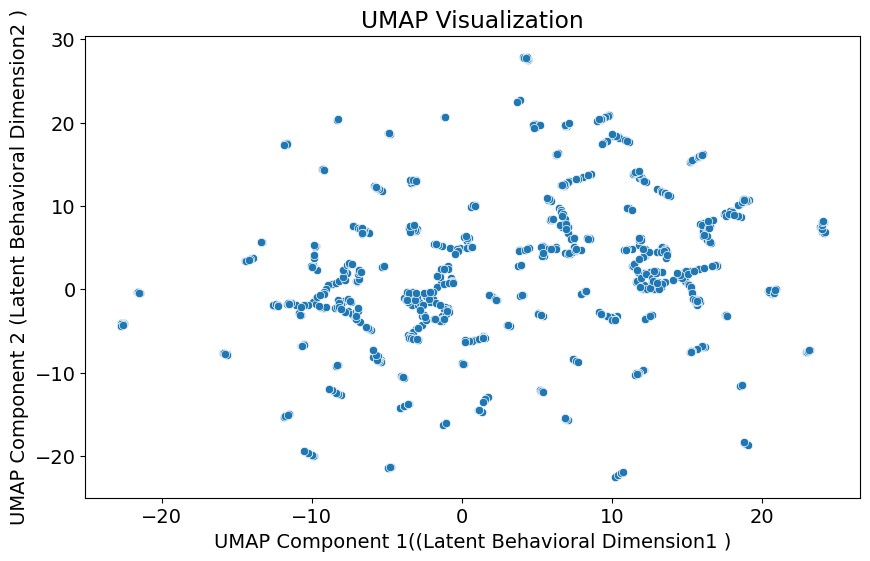

In [28]:
# # Install required libraries
# !pip install umap-learn
# !pip install seaborn matplotlib

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap

# Load your dataset (Replace this with loading your actual dataset)
# df = pd.read_csv('your_dataset.csv')

# Preprocessing: Let's focus on numerical columns for UMAP
df_clean = df[['children_count', 'income_amount', 'Days_birth', 'Days_employed', 'Count_family_members', 'Month_Balance', 'age']]

# Handle missing values if any (optional, depending on your dataset)
df_clean = df_clean.fillna(df_clean.mean())

# Normalize the data (optional, but helps with UMAP performance)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Reduce dataset size for faster processing (optional)
df_sampled = df_scaled[:1000]  # Select a sample of 1000 rows for faster processing

# Apply UMAP
umap_model = umap.UMAP(n_neighbors=5, min_dist=0.5, n_components=2, random_state=42, n_jobs=-1)
umap_results = umap_model.fit_transform(df_sampled)

# Plot the UMAP results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1], palette="viridis")
plt.title("UMAP Visualization")
plt.xlabel("UMAP Component 1((Latent Behavioral Dimension1 )")
plt.ylabel("UMAP Component 2 (Latent Behavioral Dimension2 )")
plt.show()


# Model Building

In [29]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_id               36457 non-null  int64  
 1   Gender                36457 non-null  object 
 2   Car                   36457 non-null  object 
 3   Realty                36457 non-null  object 
 4   children_count        36457 non-null  int64  
 5   income_amount         36457 non-null  float64
 6   income_type           36457 non-null  object 
 7   education_type        36457 non-null  object 
 8   Family_status         36457 non-null  object 
 9   Housing_type          36457 non-null  object 
 10  Days_birth            36457 non-null  int64  
 11  Days_employed         36457 non-null  int64  
 12  Mobile                36457 non-null  int64  
 13  Work_phone            36457 non-null  int64  
 14  Phone                 36457 non-null  int64  
 15  Email              

In [31]:
#change the target variable to binary format
def label_status(status):
    if status in {"X", "1", "2", "3", "4", "5"}:
        return 0
    elif status in {'C','0'}:
        return 1

In [32]:
df['label'] = df['Status'].apply(label_status)
df['Status'].value_counts()

,count
Status,
C,17950
X,9669
0,8456
1,276
5,76
2,19
3,6
4,5


In [33]:
X = df.drop(['label','Status'], axis = 1) # Assume that X is our independent variable

y = df['label']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Aravind Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning:

The total space of parameters 80 is smaller than n_iter=100. Running 80 iterations. For exhaustive searches, use GridSearchCV.



Best Parameters for Logistic Regression: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 100, 'C': 0.3593813663804626}
Best Cross-validation Score for Logistic Regression: 0.9643304421026683
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      5282
           1       0.95      0.98      0.96      5281

    accuracy                           0.96     10563
   macro avg       0.96      0.96      0.96     10563
weighted avg       0.96      0.96      0.96     10563

Confusion Matrix:
[[4995  287]
 [ 105 5176]]
Accuracy Score: 0.9629
ROC-AUC Score: 0.9663892641355876


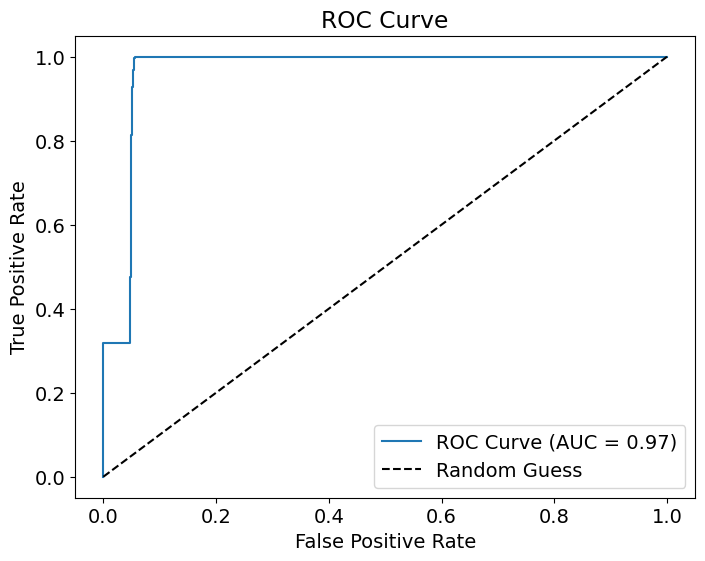

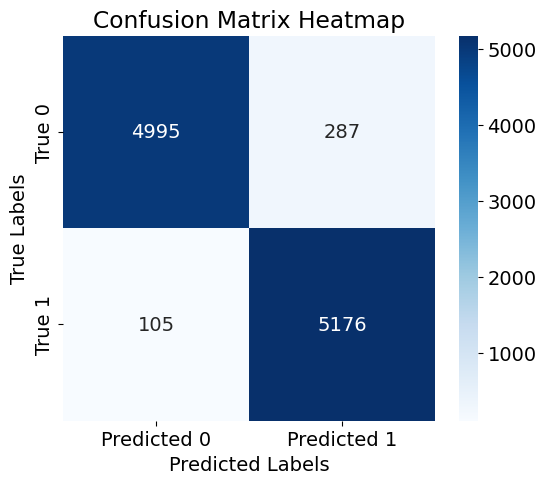

In [35]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming your DataFrame is named df
# Replace 'label' with your actual target column
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

# Check for and encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Address class imbalance using SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hyperparameters distribution for Logistic Regression
param_dist = {
    'C': np.logspace(-4, 4, 10),  # Regularization strength (log scale)
    'solver': ['lbfgs', 'liblinear'],  # Optimization algorithms
    'max_iter': [100, 200, 500, 1000],  # Maximum number of iterations
    'penalty': ['l2'],  # Regularization type (l2 is the default)
}

# RandomizedSearchCV for Logistic Regression
random_search = RandomizedSearchCV(LogisticRegression(random_state=42), param_dist, n_iter=100, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Best Parameters and Model Evaluation
print("Best Parameters for Logistic Regression:", random_search.best_params_)
print("Best Cross-validation Score for Logistic Regression:", random_search.best_score_)

# Predict on the test set with the best model
best_logreg_model = random_search.best_estimator_
y_pred = best_logreg_model.predict(X_test)
y_pred_prob = best_logreg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.4f}".format(accuracy))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Sashank Random Classifier

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


72 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Best Parameters for Random Forest: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-validation Score for Random Forest: 0.9953845061421571
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5282
           1       0.99      1.00      1.00      5281

    accuracy                           1.00     10563
   macro avg       1.00      1.00      1.00     10563
weighted avg       1.00      1.00      1.00     10563

Confusion Matrix:
[[5233   49]
 [   0 5281]]
Accuracy Score: 0.9954
ROC-AUC Score: 0.9997161600591262


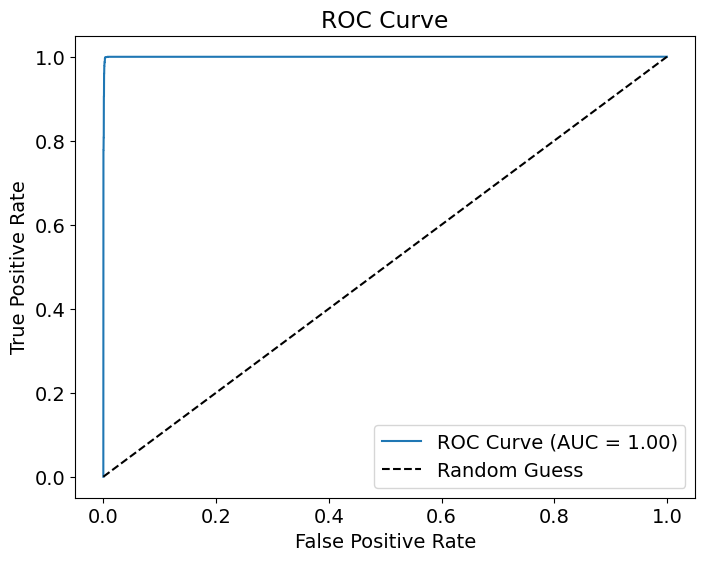

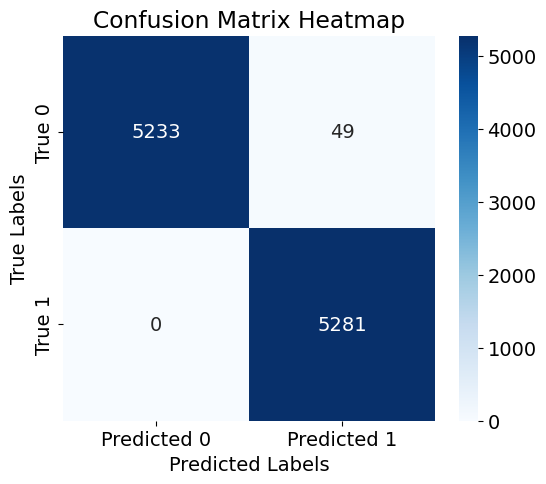

In [36]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named df
# Replace 'label' with your actual target column
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

# Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Address class imbalance using SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Optimized hyperparameters grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True],
    'max_features': ['auto', 'sqrt']
}

# GridSearchCV for RandomForestClassifier
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best Parameters and Model Evaluation
print("Best Parameters for Random Forest:", grid_search.best_params_)
print("Best Cross-validation Score for Random Forest:", grid_search.best_score_)

# Predict on the test set with the best model
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
y_pred_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.4f}".format(accuracy))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# Upendra DecisionTreeClassifier


Data encoding complete.
SMOTE completed in 1.35 seconds.
Fitting 3 folds for each of 72 candidates, totalling 216 fits
GridSearch completed in 23.04 seconds.
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5282
           1       0.99      1.00      1.00      5281

    accuracy                           1.00     10563
   macro avg       1.00      1.00      1.00     10563
weighted avg       1.00      1.00      1.00     10563

ROC-AUC Score: 1.00
Confusion Matrix:
[[5237   45]
 [   0 5281]]


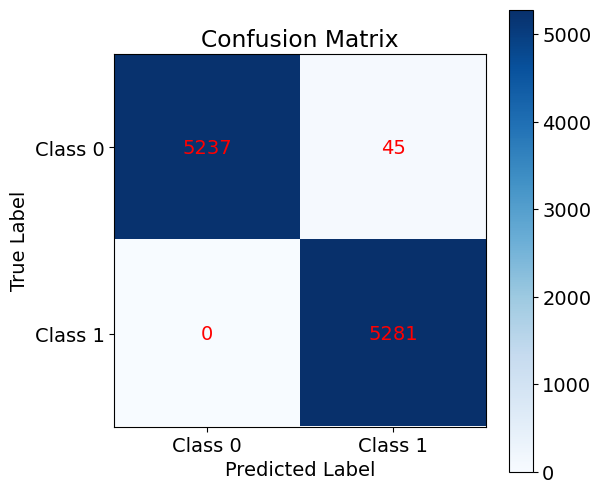

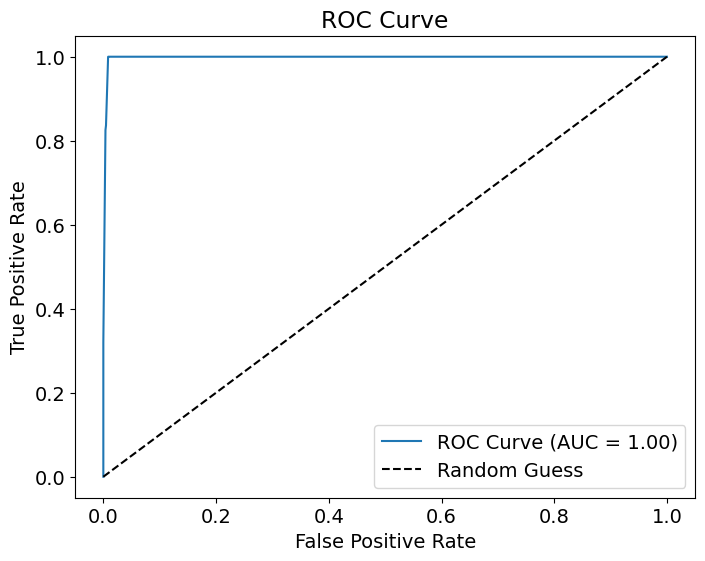

Script execution completed in 25.14 seconds.


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import time
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Timing the entire script
script_start_time = time.time()

# Assuming your DataFrame is named df
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

# Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Data encoding complete.")

# Handle class imbalance using SMOTE
start_time = time.time()
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"SMOTE completed in {time.time() - start_time:.2f} seconds.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define parameter grid for GridSearch
param_grid = {
    'criterion': ['gini', 'entropy'],        # Splitting criteria
    'max_depth': [5, 10, 15, None],          # Depth of the tree
    'min_samples_split': [2, 5, 10],         # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5]            # Minimum samples in leaf nodes
}

# Initialize DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=2, n_jobs=-1)

# Perform GridSearch
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"GridSearch completed in {time.time() - start_time:.2f} seconds.")

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the best DecisionTreeClassifier
best_dt = grid_search.best_estimator_

# Predictions using the best model
y_pred = best_dt.predict(X_test)
y_pred_prob = best_dt.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute and display ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
plt.title("Confusion Matrix")
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='red')
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"Script execution completed in {time.time() - script_start_time:.2f} seconds.")


# Lokesh xg boost


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[17:14:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Before Hyperparameter Tuning:
Accuracy: 1.00
Precision: 0.99
Recall: 1.00
ROC-AUC: 1.00
Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[17:15:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

After Hyperparameter Tuning:
Accuracy: 1.00
Precision: 0.99
Recall: 1.00
ROC-AUC: 1.00

Comparison:
Accuracy Improvement: -0.00
Precision Improvement: -0.00
Recall Improvement: 0.00
ROC-AUC Improvement: 0.00


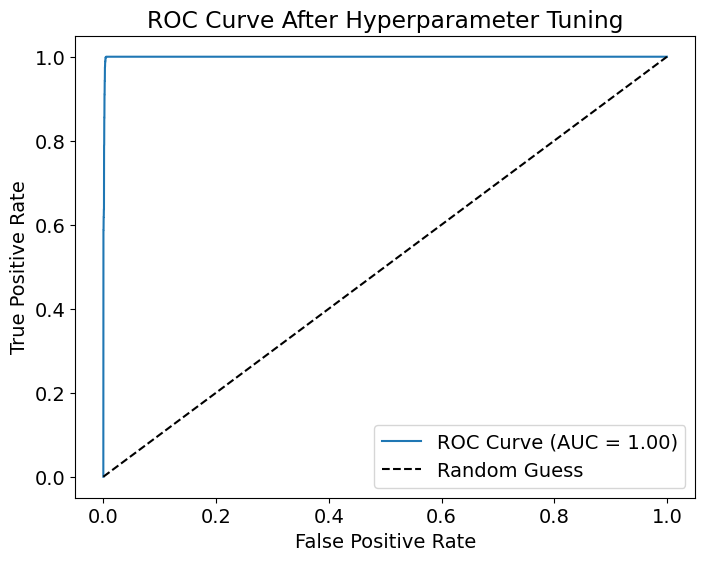

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score
import xgboost as xgb
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Assuming your cleaned dataset is named 'df'
# Replace 'label' with your actual target column name
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

# Convert to binary classification (e.g., class 1 vs. rest)
target_class = 1
y = (y == target_class).astype(int)

# Encode categorical features
categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Address class imbalance using SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)  # Adjust k_neighbors if necessary
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train XGBoost model without hyperparameter tuning
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predictions before hyperparameter tuning
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model before hyperparameter tuning
print("Before Hyperparameter Tuning:")
accuracy_before = accuracy_score(y_test, y_pred)
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
roc_auc_before = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy_before:.2f}")
print(f"Precision: {precision_before:.2f}")
print(f"Recall: {recall_before:.2f}")
print(f"ROC-AUC: {roc_auc_before:.2f}")

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model
best_model = grid_search.best_estimator_

# Predictions after hyperparameter tuning
y_pred_tuned = best_model.predict(X_test)
y_pred_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Evaluate the model after hyperparameter tuning
print("\nAfter Hyperparameter Tuning:")
accuracy_after = accuracy_score(y_test, y_pred_tuned)
precision_after = precision_score(y_test, y_pred_tuned)
recall_after = recall_score(y_test, y_pred_tuned)
roc_auc_after = roc_auc_score(y_test, y_pred_prob_tuned)

print(f"Accuracy: {accuracy_after:.2f}")
print(f"Precision: {precision_after:.2f}")
print(f"Recall: {recall_after:.2f}")
print(f"ROC-AUC: {roc_auc_after:.2f}")

# Compare metrics
print("\nComparison:")
print(f"Accuracy Improvement: {accuracy_after - accuracy_before:.2f}")
print(f"Precision Improvement: {precision_after - precision_before:.2f}")
print(f"Recall Improvement: {recall_after - recall_before:.2f}")
print(f"ROC-AUC Improvement: {roc_auc_after - roc_auc_before:.2f}")

# Plot ROC Curve (After Tuning)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_tuned)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_after:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve After Hyperparameter Tuning')
plt.legend()
plt.show()


# Adityaa Model Building

#DBScan


Best DBSCAN Results:
Best Parameters: eps=0.3, min_samples=7
Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.04      0.06     10051
           1       0.70      0.84      0.76     26406

    accuracy                           0.62     36457
   macro avg       0.39      0.44      0.41     36457
weighted avg       0.53      0.62      0.57     36457

Accuracy: 0.62
Confusion Matrix:
[[  404  9647]
 [ 4187 22219]]


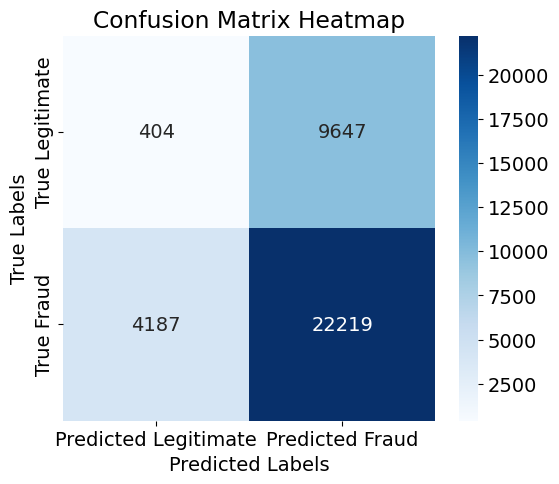

ROC-AUC Score: 0.44


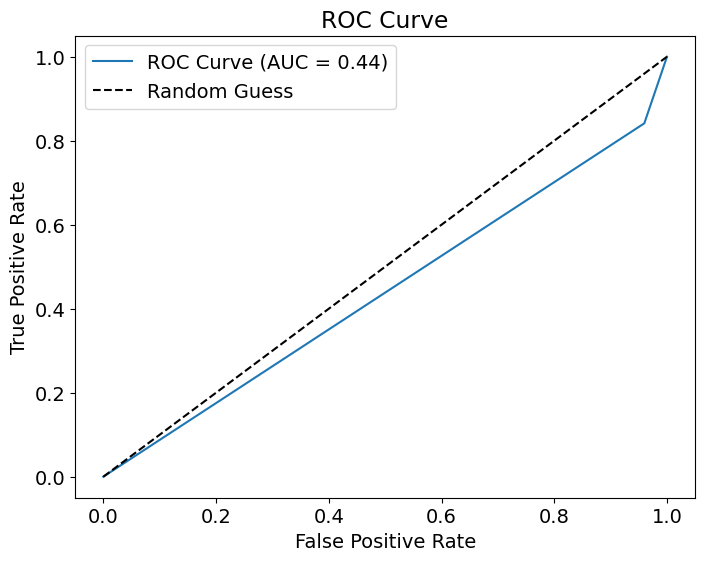

In [53]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataset is named df, and the label_status function has already been applied
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target (binary: 0 or 1)

# Identify categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns

# Encode categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fine-tuning DBSCAN parameters
best_f1 = 0
best_eps = None
best_min_samples = None
best_model = None
best_pred = None

eps_values = [0.3, 0.4, 0.5, 0.6]  # Parameter range for `eps`
min_samples_values = [3, 5, 7]     # Parameter range for `min_samples`

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        # Convert DBSCAN labels to binary
        dbscan_pred = (dbscan_labels == -1).astype(int)  # Noise = 1 (Fraud), Core samples = 0 (Legitimate)

        # Evaluate only if at least two classes are present
        if len(set(dbscan_pred)) > 1:
            report = classification_report(y, dbscan_pred, output_dict=True)

            # Handle binary class names dynamically
            fraud_label = str(sorted(y.unique())[1])  # Binary '1' (Fraud)
            f1 = report[fraud_label]['f1-score']  # Accessing the F1-score for the Fraud class

            if f1 > best_f1:
                best_f1 = f1
                best_eps = eps
                best_min_samples = min_samples
                best_model = dbscan
                best_pred = dbscan_pred

# Evaluate the best model
print("\nBest DBSCAN Results:")
print(f"Best Parameters: eps={best_eps}, min_samples={best_min_samples}")
print("Classification Report:")
print(classification_report(y, best_pred))

# Print accuracy
accuracy = accuracy_score(y, best_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y, best_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['True Legitimate', 'True Fraud'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Calculate ROC Curve
fpr, tpr, _ = roc_curve(y, best_pred)
roc_auc = roc_auc_score(y, best_pred)
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Light GBM(Gradient Boosting Model)

In [39]:
pip install "dask[dataframe]"

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 5.3 MB/s eta 0:00:00


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 21125, number of negative: 21124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 42249, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

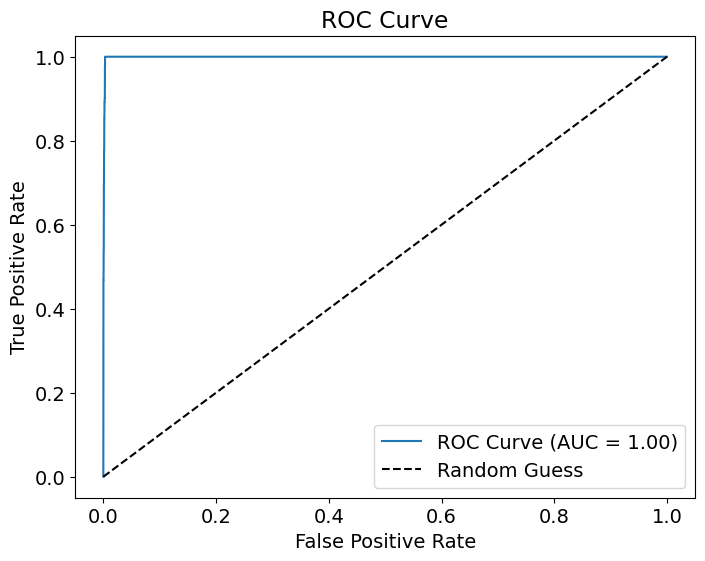

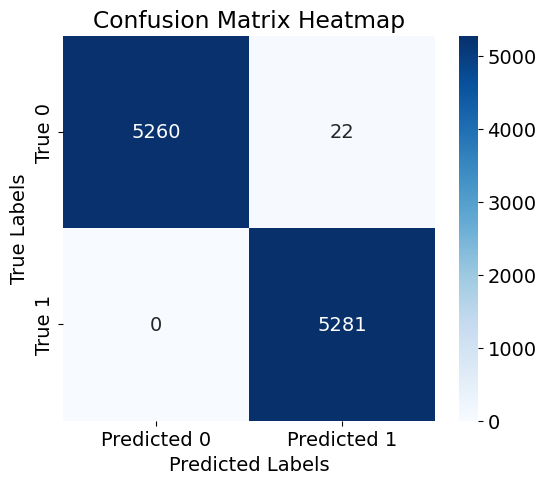

In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named df
# Replace 'label' with your actual target column
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

# Check for and encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Apply DBSCAN for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardize the data before DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
X['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Address class imbalance using SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define parameter grid for LightGBM
param_grid = {
    'num_leaves': [20, 30, 40],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'min_child_samples': [20, 30],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.0, 0.1]
}

# RandomizedSearchCV for LightGBM with class weights
random_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, class_weight='balanced'),  # Use balanced class weights
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings sampled
    cv=3,
    scoring='f1',  # Using F1-score to better handle imbalanced data
    n_jobs=-1,
    verbose=1
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best Parameters and Model Evaluation
print("Best Parameters for LightGBM:", random_search.best_params_)
print("Best Cross-validation F1-score for LightGBM:", random_search.best_score_)

# Predict on the test set with the best model
best_lgb_model = random_search.best_estimator_
y_pred = best_lgb_model.predict(X_test)
y_pred_prob = best_lgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.4f}".format(accuracy))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# Conclusion

In conclusion, while the **Random Forest Classifier** outperforms other models in predictive accuracy and overall metrics, the **DBSCAN** algorithm proves valuable for anomaly detection, particularly in identifying fraudulent cases. With its unsupervised nature, DBSCAN achieves a recall of 84% for fraud detection, effectively uncovering anomalies without requiring labeled data. This highlights the potential of combining both approaches—Random Forest for high accuracy and DBSCAN for robust anomaly detection—to create a comprehensive fraud detection system.

# Insights

Class Imbalance Handling: Application of SMOTE in managing the class imbalance showed success in all models as it provided fairness on both performance measures of the two classes1
.
Feature Importance: The Random Forest model, therefore, gives better results mainly because it detects additional complex and non-linear patterns. This means that some interaction of features is very relevant to the target variable of interest.
Hyperparameter Sensitivity: Another noteworthy aspect using the present results is that there is a significantly better performance of the XGBoost after hyperparameters have been tuned.
Model Complexity vs. Performance: Since simple models such as Decision Trees yield high performance, the current dataset may be well-solvable with simple decision boundaries.

# Future Work

Future Work
Neural Network Architectures: Implementing deep learning models such as Multi-Layer Perceptrons (MLPs) or Convolutional Neural Networks (CNNs) could potentially capture complex non-linear relationships in the data.

Automated Machine Learning (AutoML): Utilizing AutoML tools like Auto-sklearn or TPOT to automatically search for the best models and hyperparameters could uncover additional performance gains.

Feature Selection Techniques: Applying advanced feature selection methods such as Recursive Feature Elimination (RFE) or LASSO regularization could help identify the most important predictors and potentially improve model performance.
